# Variáveis Aleatórias Discretas
### Valor esperado, variância, Distribuição Binomial e Distribuição de Poisson

Formaliza o conceito de **variável aleatória discreta** e cobre as duas distribuições
discretas mais usadas em estatística aplicada: **Binomial** e **Poisson**. Cada seção
resolve um exemplo clássico primeiro pela fórmula (do jeito que se faz no papel) e depois
com `scipy.stats`, comparando os dois resultados.

Pré-requisito: [Módulo 02 — Probabilidade](../02_Probabilidade)

### 1. Importação das bibliotecas

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'font.size': 12})

## 2. Variável aleatória discreta

Uma **variável aleatória** associa um número real a cada resultado de um experimento
aleatório. Ela é **discreta** quando assume um número finito (ou infinito enumerável) de
valores — por exemplo, o número de caras em 4 lançamentos de moeda, ou o número de peças
defeituosas em um lote.

Toda variável aleatória discreta $X$ tem uma função de probabilidade $P(X=x_i)$ que
satisfaz:

$$P(x_i) \geq 0 \quad \text{e} \quad \sum_i P(x_i) = 1$$

## 3. Valor esperado e variância

O **valor esperado** ($E(X)$ ou $\mu$) é a média ponderada pelos pesos de probabilidade:

$$E(X) = \mu = \sum_i x_i \cdot P(x_i)$$

A **variância** mede a dispersão em torno da média:

$$Var(X) = \sigma^2 = \sum_i (x_i - \mu)^2 \cdot P(x_i), \qquad \sigma = \sqrt{Var(X)}$$

### Exemplo — lançamento de moedas

No lançamento de 4 moedas honestas, seja $X$ o número de caras obtidas. A distribuição de
$X$ é conhecida (é um caso particular da Binomial que veremos a seguir, com $n=4$ e
$p=0{,}5$): $S=\{0,1,2,3,4\}$ com $P(0)=P(4)=0{,}0625$, $P(1)=P(3)=0{,}25$ e
$P(2)=0{,}375$.

In [2]:
# Espaço amostral: número de caras em 4 lançamentos de moeda
x = np.array([0, 1, 2, 3, 4])
p = np.array([0.0625, 0.25, 0.375, 0.25, 0.0625])
print("Soma das probabilidades:", p.sum())  # tem que dar 1.0

# Valor esperado: E(X) = soma(xi * P(xi))
E_X = np.sum(x * p)

# Variância: Var(X) = soma((xi - E(X))^2 * P(xi))
Var_X = np.sum((x - E_X) ** 2 * p)
DP_X = np.sqrt(Var_X)

print(f"E(X)   = {E_X}")
print(f"Var(X) = {Var_X}")
print(f"DP(X)  = {DP_X}")

Soma das probabilidades: 1.0
E(X)   = 2.0
Var(X) = 1.0
DP(X)  = 1.0


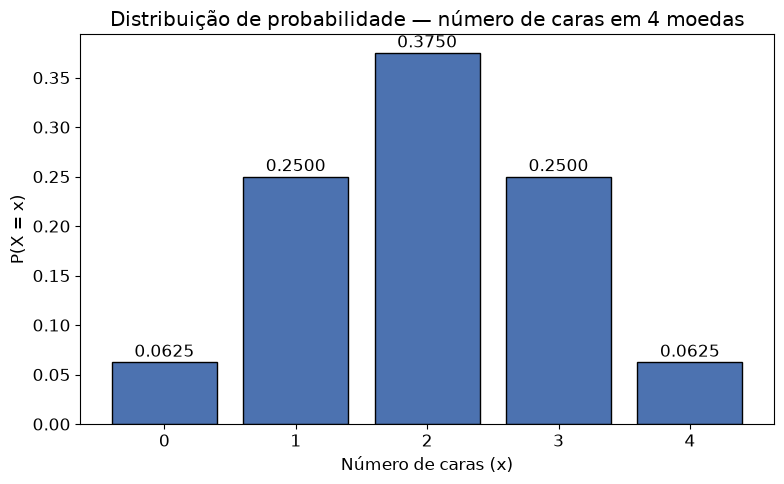

In [3]:
# Gráfico da distribuição de probabilidade
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, p, color='#4C72B0', edgecolor='black')
ax.set_title('Distribuição de probabilidade — número de caras em 4 moedas')
ax.set_xlabel('Número de caras (x)')
ax.set_ylabel('P(X = x)')
ax.set_xticks(x)
for xi, pi in zip(x, p):
    ax.annotate(f'{pi:.4f}', xy=(xi, pi), xytext=(0, 4),
                textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('img_valor_esperado_moedas.png', dpi=110)
plt.show()

Essa distribuição — número de "sucessos" em repetições independentes de um
experimento com dois resultados possíveis — é exatamente o que a **Distribuição
Binomial** generaliza.

## 4. Distribuição Binomial

Usa-se a Binomial quando o experimento é composto de $n$ repetições **independentes** de
um ensaio de Bernoulli (dois resultados possíveis: "sucesso" com probabilidade $p$, ou
"fracasso" com probabilidade $1-p$):

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad \binom{n}{k} = \frac{n!}{k!(n-k)!}$$

com $E(X) = np$ e $Var(X) = np(1-p)$.

### Exemplo — controle de qualidade

Um lote é amostrado, com reposição, e sabe-se que 10% das peças produzidas são
defeituosas. Numa amostra de 15 peças, qual a probabilidade de: a) nenhuma defeituosa;
b) exatamente 3 defeituosas; c) pelo menos 1 defeituosa; d) entre 3 e 6 defeituosas
(exclusive); e) de 3 a 6 defeituosas (inclusive)?

In [4]:
n, p_def = 15, 0.10

def binomial_manual(n, k, p):
    """P(X = k) pela fórmula fechada."""
    return math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

a = binomial_manual(n, 0, p_def)                                  # a) nenhuma defeituosa
b = binomial_manual(n, 3, p_def)                                  # b) exatamente 3
c = 1 - a                                                         # c) pelo menos 1
d = sum(binomial_manual(n, k, p_def) for k in range(4, 6))        # d) entre 3 e 6
e = sum(binomial_manual(n, k, p_def) for k in range(3, 7))        # e) de 3 a 6

for label, val in zip('abcde', [a, b, c, d, e]):
    print(f"{label}) {val:.4%}")

a) 20.5891%
b) 12.8505%
c) 79.4109%
d) 5.3306%
e) 18.3750%


In [5]:
# Mesmas contas com scipy.stats.binom
dist = stats.binom(n=n, p=p_def)

a_sp = dist.pmf(0)
b_sp = dist.pmf(3)
c_sp = dist.sf(0)                        # sf = 1 - cdf = P(X > 0)
d_sp = dist.pmf(4) + dist.pmf(5)
e_sp = dist.pmf([3, 4, 5, 6]).sum()

print("Fórmula manual  x  scipy.stats.binom:")
for label, manual, sp in zip('abcde', [a, b, c, d, e], [a_sp, b_sp, c_sp, d_sp, e_sp]):
    print(f"  {label}) manual={manual:.4%}  scipy={sp:.4%}  diferença={abs(manual - sp):.2e}")

Fórmula manual  x  scipy.stats.binom:
  a) manual=20.5891%  scipy=20.5891%  diferença=8.33e-17
  b) manual=12.8505%  scipy=12.8505%  diferença=1.39e-16
  c) manual=79.4109%  scipy=79.4109%  diferença=0.00e+00
  d) manual=5.3306%  scipy=5.3306%  diferença=2.08e-17
  e) manual=18.3750%  scipy=18.3750%  diferença=1.39e-16


### Exemplo — probabilidade "pelo menos 1"

Numa fila de 9 clientes de uma agência, a probabilidade de cada cliente precisar de
orientação sobre um novo serviço é $p=0{,}15$. Qual a probabilidade de pelo menos 1 cliente
na fila precisar de orientação?

In [6]:
n2, p2 = 9, 0.15
prob_pelo_menos_1 = stats.binom(n=n2, p=p2).sf(0)   # 1 - P(nenhum)
print(f"P(pelo menos 1) = {prob_pelo_menos_1:.4%}")

P(pelo menos 1) = 76.8383%


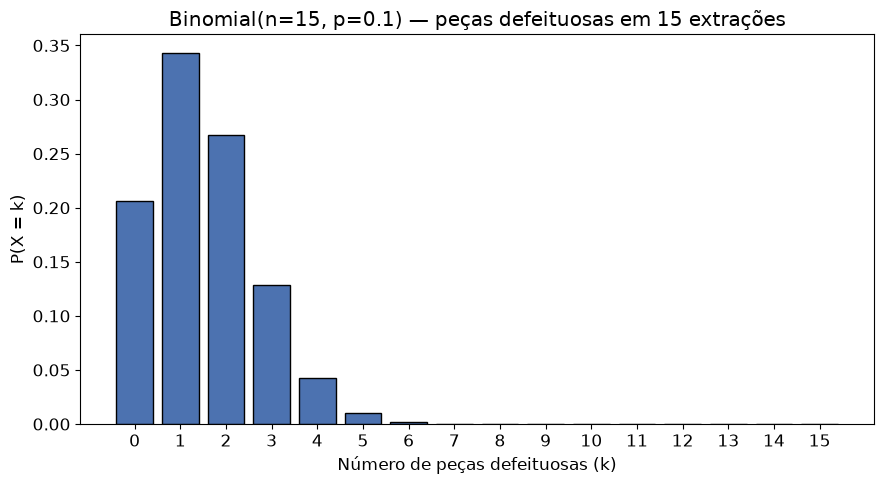

In [7]:
# PMF completa do primeiro exemplo (n=15, p=0.10)
k_vals = np.arange(0, n + 1)
pmf_vals = stats.binom(n=n, p=p_def).pmf(k_vals)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(k_vals, pmf_vals, color='#4C72B0', edgecolor='black')
ax.set_title(f'Binomial(n={n}, p={p_def}) — peças defeituosas em 15 extrações')
ax.set_xlabel('Número de peças defeituosas (k)')
ax.set_ylabel('P(X = k)')
ax.set_xticks(k_vals)
plt.tight_layout()
plt.savefig('img_binomial_pecas.png', dpi=110)
plt.show()

## 5. Distribuição de Poisson

Modela o número de ocorrências de um evento **raro** em um intervalo fixo, quando o
número de "tentativas" $n$ é grande e a probabilidade $p$ de cada uma é pequena. Nesse
regime, a Binomial(n, p) é bem aproximada pela Poisson com $\lambda = np$:

$$P(X = k) = \frac{e^{-\lambda}\lambda^k}{k!}, \qquad E(X) = Var(X) = \lambda$$

### Exemplo — sinistros de seguro

Uma seguradora de automóveis segura 100 veículos de uma empresa. A taxa histórica de
roubo é de 3,5% ao ano. Qual a probabilidade de, no máximo, 2 veículos serem roubados no
próximo ano?

In [8]:
lam1 = 100 * 0.035  # lambda = n * p
print(f"lambda = {lam1}")

def poisson_manual(lam, k):
    return math.exp(-lam) * (lam ** k) / math.factorial(k)

p_ate_2_manual = sum(poisson_manual(lam1, k) for k in range(0, 3))
p_ate_2_scipy = stats.poisson(mu=lam1).cdf(2)

print(f"P(X<=2) manual = {p_ate_2_manual:.4%}")
print(f"P(X<=2) scipy  = {p_ate_2_scipy:.4%}")

lambda = 3.5000000000000004
P(X<=2) manual = 32.0847%
P(X<=2) scipy  = 32.0847%


### Exemplo — Poisson como aproximação da Binomial

Um lote de 35 peças tem taxa de defeito de 20%. Qual a probabilidade de exatamente 3
peças saírem defeituosas? Dá para resolver como Binomial(n=35, p=0,20) exata ou como
aproximação de Poisson($\lambda = 35 \times 0{,}20 = 7$) — comparando as duas fica claro
o quanto a aproximação se afasta quando $n$ não é tão grande.

In [9]:
n3, p3 = 35, 0.20
lam2 = n3 * p3

exato_binomial = stats.binom(n=n3, p=p3).pmf(3)
aprox_poisson = stats.poisson(mu=lam2).pmf(3)

print(f"Binomial exata           P(X=3) = {exato_binomial:.4%}")
print(f"Poisson (lambda={lam2})  P(X=3) = {aprox_poisson:.4%}")
print(f"Diferença absoluta: {abs(exato_binomial - aprox_poisson):.4%}")

Binomial exata           P(X=3) = 4.1484%
Poisson (lambda=7.0)  P(X=3) = 5.2129%
Diferença absoluta: 1.0645%


### Exemplo — dois eventos no mesmo problema

Numa loja, 5% das peças vendidas são trocadas. Foram vendidas 200 peças no mês. Qual a
probabilidade de: a) nenhuma troca; b) pelo menos 3 trocas?

In [10]:
lam3 = 200 * 0.05
dist3 = stats.poisson(mu=lam3)

a3 = dist3.pmf(0)
b3 = dist3.sf(2)   # P(X >= 3) = 1 - P(X <= 2)

print(f"a) P(X=0)  = {a3:.4%}")
print(f"b) P(X>=3) = {b3:.4%}")

a) P(X=0)  = 0.0045%
b) P(X>=3) = 99.7231%


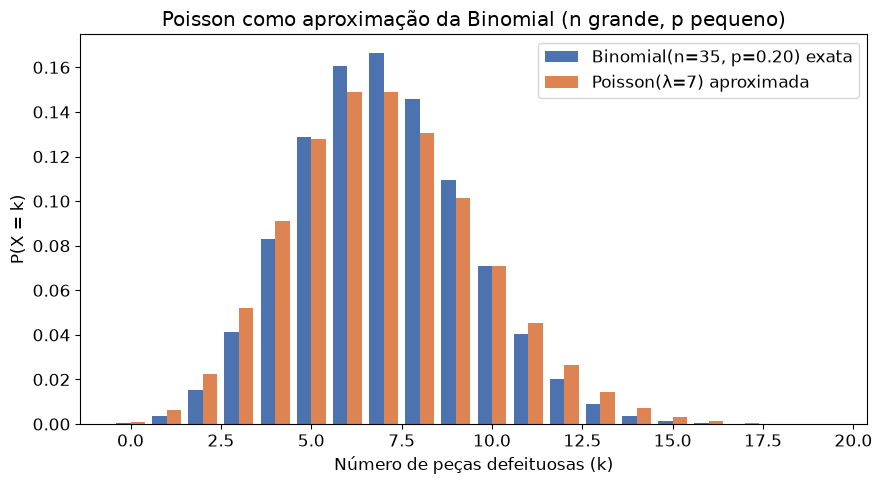

In [11]:
# Comparando visualmente Binomial(35, 0.20) exata x Poisson(lambda=7) aproximada
k_vals = np.arange(0, 20)
binom_pmf = stats.binom(n=35, p=0.20).pmf(k_vals)
poisson_pmf = stats.poisson(mu=7).pmf(k_vals)

fig, ax = plt.subplots(figsize=(9, 5))
width = 0.4
ax.bar(k_vals - width/2, binom_pmf, width, label='Binomial(n=35, p=0.20) exata', color='#4C72B0')
ax.bar(k_vals + width/2, poisson_pmf, width, label='Poisson(λ=7) aproximada', color='#DD8452')
ax.set_title('Poisson como aproximação da Binomial (n grande, p pequeno)')
ax.set_xlabel('Número de peças defeituosas (k)')
ax.set_ylabel('P(X = k)')
ax.legend()
plt.tight_layout()
plt.savefig('img_poisson_aproxima_binomial.png', dpi=110)
plt.show()

## 6. Exercícios de fixação

1. Uma fábrica recusa 20% das peças produzidas por controle de qualidade. Num lote de 10
   peças, qual a probabilidade de exatamente 2 serem recusadas?
2. Uma central telefônica recebe, em média, 7 chamadas por minuto. Qual a probabilidade de
   receber mais de 10 chamadas em um minuto?

In [12]:
resp1 = stats.binom(n=10, p=0.20).pmf(2)
print(f"1) P(X=2) = {resp1:.4%}")

resp2 = stats.poisson(mu=7).sf(10)   # P(X>10) = 1 - P(X<=10)
print(f"2) P(X>10) = {resp2:.4%}")

1) P(X=2) = 30.1990%
2) P(X>10) = 9.8521%


## Próximos passos

Este notebook cobriu a parte **discreta** da variável aleatória. O próximo,
[`variaveis_aleatorias_continuas.ipynb`](variaveis_aleatorias_continuas.ipynb), cobre a
parte **contínua** — Uniforme, Exponencial, Normal e t de Student.

## Bibliografia
- TRIOLA, Mario F. *Introdução à Estatística*. 8. ed. Rio de Janeiro: LTC, 2005.
- BUSSAB, Wilton O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- MEYER, Paul L. *Probabilidade: Aplicações à Estatística*. 2. ed. Rio de Janeiro: LTC, 1983.
- MONTGOMERY, Douglas C.; RUNGER, George C. *Applied Statistics and Probability for Engineers*. 7. ed. Wiley, 2018.